In [2]:
import pandas as pd

# Load full dataset
data = pd.read_csv("creditcard.csv")

# Take a smaller sample (e.g., 10,000 rows)
small_data = data.sample(n=10000, random_state=42)

# Save and upload the smaller dataset
small_data.to_csv("creditcard_small.csv", index=False)


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import joblib

In [6]:
# Separate features and target variable
X = data.drop(columns=['Class'])  # Features
y = data['Class']  # Target (0 = legitimate, 1 = fraud)

In [7]:
# Data Preprocessing
X = data.drop(columns=['Class'])  # Features
y = data['Class']  # Target

In [8]:
# Standardize features before resampling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Handle Imbalanced Data using SMOTE
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

In [10]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [11]:
# Train Model (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
# Evaluate Model
y_pred = model.predict(X_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

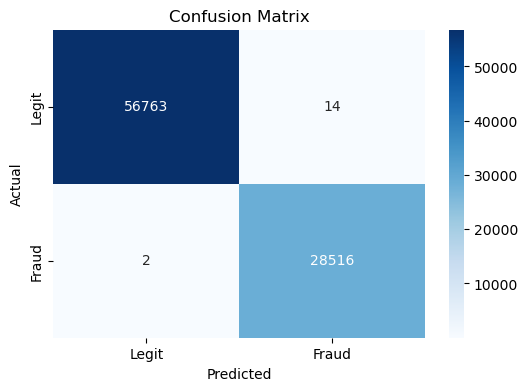

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [23]:
# Display Evaluation Metrics
print("Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

Model Evaluation:
Accuracy: 0.9998
Precision: 0.9995
Recall: 0.9999
F1-score: 0.9997
Confusion Matrix:
[[56763    14]
 [    2 28516]]


In [24]:
# Feature Importance
feature_importances = model.feature_importances_
feature_names = data.drop(columns=['Class']).columns
sorted_indices = np.argsort(feature_importances)[::-1]

print("\nFeature Importance Ranking:")
for idx in sorted_indices[:10]:  # Show top 10 features
    print(f"{feature_names[idx]}: {feature_importances[idx]:.4f}")



Feature Importance Ranking:
V14: 0.1974
V10: 0.1201
V12: 0.1025
V17: 0.0998
V4: 0.0812
V16: 0.0626
V11: 0.0571
V3: 0.0526
V2: 0.0403
V9: 0.0263


In [25]:
# CLI for Testing with Default Values
print("\nFraud Detection System - Test with Sample Transaction")
loaded_model = joblib.load("fraud_detection_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")


Fraud Detection System - Test with Sample Transaction


In [26]:
# Sample Input Features
sample_transaction = [0.5, -1.2, 2.1, 0.8, -0.9, 1.3, -2.5, 0.7, 1.9, -1.1, 
                       0.6, -0.4, 1.8, -2.2, 0.9, 1.1, -1.7, 2.3, -0.8, 1.5, 
                       0.4, -2.0, 1.7, -0.3, 2.0, 0.2, -1.4, 1.6, -0.5, 100.0]

In [27]:
# Process input
input_array = np.array(sample_transaction).reshape(1, -1)
input_scaled = loaded_scaler.transform(pd.DataFrame(input_array, columns=feature_names))


In [28]:
# Prediction
prediction = loaded_model.predict(input_scaled)
if prediction[0] == 1:
    print("🚨 Fraudulent Transaction Detected!")
else:
    print("✅ Transaction is Legitimate.")


✅ Transaction is Legitimate.
